In [2]:
import numpy as np
import matplotlib.pyplot as plt
from privacy_estimates.experiments.aml import JobList

/anaconda/envs/privacy-estimates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# first real, then synthetic - these are jobs for AgNews without canaries
jobs = JobList.from_urls([
    'https://ml.azure.com/runs/lemon_rain_ndr9xk001w?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#', 
    'https://ml.azure.com/runs/sad_gas_8x5s6khn5k?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#'
    ])

In [4]:
job = jobs[0]
synthetic_job = jobs[1]

In [5]:
metrics = job.get_node('compute_utility_real').get_metrics()
metrics_synthetic = synthetic_job.get_node('compute_utility_synthetic').get_metrics()

In [6]:
metrics.keys()

dict_keys(['loss', 'epoch', 'learning_rate', 'eval_samples_per_second', 'eval_accuracy', 'eval_auc', 'eval_precision', 'eval_loss', 'eval_runtime', 'eval_f1', 'eval_recall', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss'])

In [7]:
print(f"Real AUC: {metrics['eval_auc'][-1]}")
print(f"Synthetic AUC: {metrics_synthetic['eval_auc'][-1]}")
print(f"Real accuracy: {metrics['eval_accuracy'][-1]}")
print(f"Synthetic accuracy: {metrics_synthetic['eval_accuracy'][-1]}")

Real AUC: 0.9930426592797784
Synthetic AUC: 0.9700661703601108
Real accuracy: 0.9467105263157894
Synthetic accuracy: 0.8923684210526316


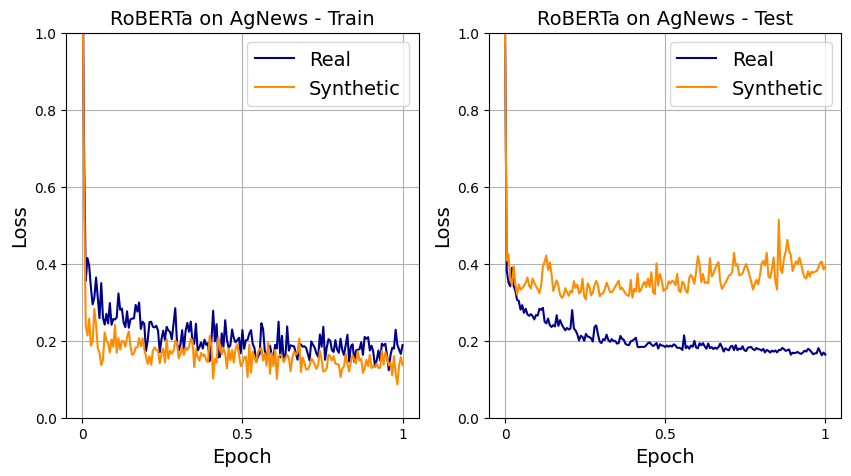

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# first do train real vs synthetic
axes[0].plot(np.linspace(0, 1, len(metrics['loss'])), metrics['loss'], color = 'darkblue', label='Real')
axes[0].plot(np.linspace(0, 1, len(metrics_synthetic['loss'])), metrics_synthetic['loss'], color = 'darkorange', label='Synthetic')
axes[0].set_xticks([0, 0.5, 1])
axes[0].set_xticklabels([0, 0.5, 1])
axes[0].legend(fontsize=14)
axes[0].grid()
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('Loss', fontsize=14)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('RoBERTa on AgNews - Train', fontsize=14)

# now do eval loss
axes[1].plot(np.linspace(0, 1, len(metrics['eval_loss'])), metrics['eval_loss'], color = 'darkblue', label='Real')
axes[1].plot(np.linspace(0, 1, len(metrics_synthetic['eval_loss'])), metrics_synthetic['eval_loss'], color = 'darkorange', label='Synthetic')
axes[1].set_xticks([0, 0.5, 1])
axes[1].set_xticklabels([0, 0.5, 1])
axes[1].legend(fontsize=14)
axes[1].grid()
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('Loss', fontsize=14)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('RoBERTa on AgNews - Test', fontsize=14)

plt.savefig('figures/utility_agnews.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

plt.show()